# Who Vanished on the Spaceship Titanic?

The Spaceship Titanic collided with a hidden anomaly in space, and almost
half of its 8,693 passengers were swept into another dimension.

The question I set out to answer: **could we have predicted who would vanish?**
And if so, what was the biggest clue?

## How I approached it

I started with the raw passenger records, cleaned up the missing pieces using
logic instead of guesswork, and built new clues from the data (like who traveled
together and how much each person spent). Then I trained a model to spot the
pattern. Below are the clues that mattered most.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/Users/ayeshashimu/Downloads/train.csv')
test = pd.read_csv('/Users/ayeshashimu/Downloads/test.csv')

print(train.shape)
print(test.shape)

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [4]:
train['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

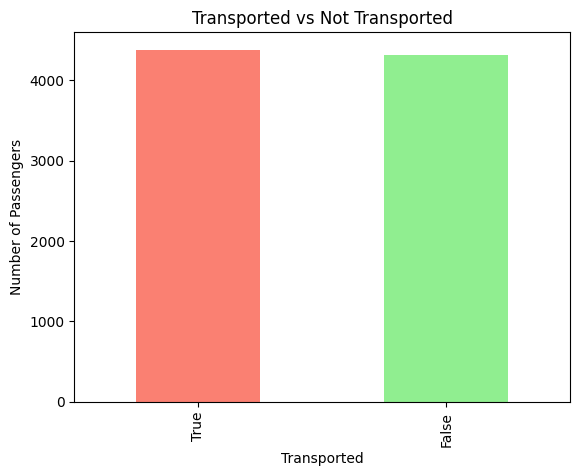

In [5]:
train['Transported'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Transported vs Not Transported')
plt.ylabel('Number of Passengers')
plt.show()

In [6]:
train.groupby('HomePlanet')['Transported'].mean()

HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64

In [7]:
train.groupby('CryoSleep')['Transported'].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

In [8]:
train.groupby('Destination')['Transported'].mean()

Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64

In [9]:
train.groupby('VIP')['Transported'].mean()

VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

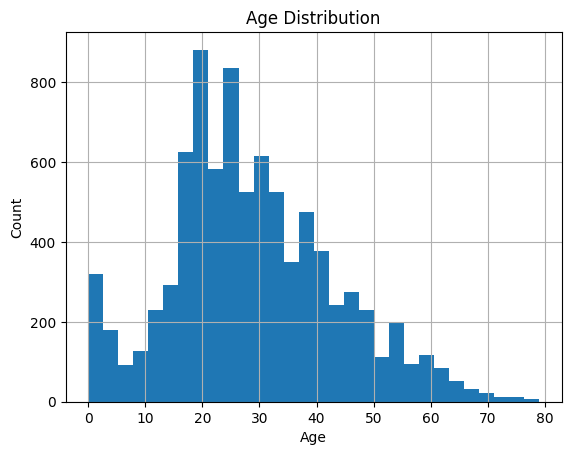

In [10]:
train['Age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [11]:
train.groupby(train['Age'] // 10 * 10)['Transported'].mean()

Age
0.0     0.711340
10.0    0.532792
20.0    0.469225
30.0    0.458790
40.0    0.506679
50.0    0.493716
60.0    0.475962
70.0    0.434783
Name: Transported, dtype: float64

In [12]:
spending = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train[spending].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,224.687617,458.077203,173.729169,311.138778,304.854791
std,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,47.000000,76.000000,27.000000,59.000000,46.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [13]:
train['TotalSpending'] = train[spending].sum(axis=1)
train.groupby(train['TotalSpending'] == 0)['Transported'].mean()

TotalSpending
False    0.298611
True     0.786477
Name: Transported, dtype: float64

In [14]:
train['Group'] = train['PassengerId'].str.split('_').str[0]
train['GroupSize'] = train.groupby('Group')['Group'].transform('count')
train['IsAlone'] = train['GroupSize'] == 1

train.groupby('IsAlone')['Transported'].mean()

IsAlone
False    0.566872
True     0.452445
Name: Transported, dtype: float64

In [15]:
train['Deck'] = train['Cabin'].str.split('/').str[0]   # B
train['Side'] = train['Cabin'].str.split('/').str[2]   # P

train.groupby('Deck')['Transported'].mean()
train.groupby('Side')['Transported'].mean()

Side
P    0.451260
S    0.555037
Name: Transported, dtype: float64

In [16]:
def add_features(df):
    df['Group'] = df['PassengerId'].str.split('_').str[0]
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone'] = df['GroupSize'] == 1         
    df['Deck'] = df['Cabin'].str.split('/').str[0]
    df['Side'] = df['Cabin'].str.split('/').str[2]
    spending = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
    df['TotalSpending'] = df[spending].sum(axis=1)
    return df

In [17]:
train = add_features(train)
test = add_features(test)
print(train.shape)
print(test.shape)

(8693, 20)
(4277, 19)


In [21]:
for df in [train, test]:
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)
    df['HomePlanet'] = df['HomePlanet'].fillna('Unknown')
    df['Destination'] = df['Destination'].fillna('Unknown')
    df['Deck'] = df['Deck'].fillna('Unknown')
    df['Side'] = df['Side'].fillna('Unknown')
    df['Age'] = df['Age'].fillna(df['Age'].median())

In [19]:
print(train[['CryoSleep','HomePlanet','Destination','Deck','Side','Age']].isnull().sum())

CryoSleep      0
HomePlanet     0
Destination    0
Deck           0
Side           0
Age            0
dtype: int64


In [23]:
for df in [train, test]:
    spending = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
    df[spending] = df[spending].fillna(0)
    df['VIP'] = df['VIP'].fillna(False).astype(bool)

In [24]:
features = ['CryoSleep','HomePlanet','Destination','Deck','Side',
            'Age','GroupSize','IsAlone','VIP','TotalSpending',
            'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

X = pd.get_dummies(train[features])
X_test = pd.get_dummies(test[features])
y = train['Transported']

print(X.shape, X_test.shape)

(8693, 31) (4277, 31)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = LogisticRegression(max_iter=1000)
scores = cross_val_score(baseline, X, y, cv=cv)
print("Baseline average:", scores.mean())

Baseline average: 0.7902909691759679


In [45]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)
scores = cross_val_score(gb, X, y, cv=cv)
print("Gradient Boosting average:", scores.mean())

Gradient Boosting average: 0.8058196482112454


In [28]:
!pip install lightgbm


zsh:1: command not found: pip


In [29]:
!pip3 install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.4 MB/s  0:00:00m 2.4 MB/s eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [46]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)
scores = cross_val_score(lgbm, X, y, cv=cv)
print("LightGBM average:", scores.mean())

LightGBM average: 0.799148486194002


In [31]:
train = pd.read_csv('/Users/ayeshashimu/Downloads/train.csv')
test  = pd.read_csv('/Users/ayeshashimu/Downloads/test.csv')

In [32]:
spend = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for df in [train, test]:
    spent = df[spend].sum(axis=1)
    df.loc[df['CryoSleep'].isna() & (spent > 0), 'CryoSleep'] = False
    df.loc[df['CryoSleep'].isna() & (spent == 0), 'CryoSleep'] = True

In [44]:
def finish_prep(df):
    # features
    df['Group'] = df['PassengerId'].str.split('_').str[0]
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone'] = df['GroupSize'] == 1
    df['Deck'] = df['Cabin'].str.split('/').str[0]
    df['Side'] = df['Cabin'].str.split('/').str[2]
    df[spend] = df[spend].fillna(0)
    df['TotalSpending'] = df[spend].sum(axis=1)
    # fill the rest
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)
    df['VIP'] = df['VIP'].fillna(False).astype(bool)
    for col in ['HomePlanet','Destination','Deck','Side']:
        df[col] = df[col].fillna('Unknown')
    df['Age'] = df['Age'].fillna(df['Age'].median())
    return df

train = finish_prep(train)
test  = finish_prep(test)

features = ['CryoSleep','HomePlanet','Destination','Deck','Side','Age',
            'GroupSize','IsAlone','VIP','TotalSpending'] + spend
X = pd.get_dummies(train[features])
X_test = pd.get_dummies(test[features])
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)
y = train['Transported']
print(X.shape, X_test.shape)

(8693, 31) (4277, 31)


## Clue #1: Were they awake or asleep?

The strongest signal by far was CryoSleep, whether a passenger chose to be
frozen asleep in their pod for the journey.

Passengers who were asleep were transported about **82%** of the time. Those
awake, only **33%**. Being asleep in a pod was almost a one way ticket to the
other dimension.

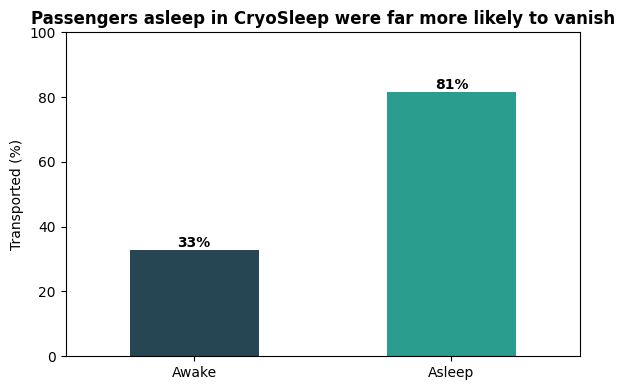

In [53]:
import matplotlib.pyplot as plt

rates = train.groupby('CryoSleep')['Transported'].mean() * 100
ax = rates.plot(kind='bar', color=['#264653','#2A9D8F'], figsize=(6,4))
plt.title('Passengers asleep in CryoSleep were far more likely to vanish',
          fontsize=12, weight='bold')
plt.ylabel('Transported (%)'); plt.xlabel('')
plt.xticks([0,1], ['Awake','Asleep'], rotation=0)
for i, v in enumerate(rates):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', weight='bold')
plt.ylim(0,100); plt.tight_layout(); plt.show()

## Clue #2: Did they spend any money?

The next clue hides in the bills. Passengers who spent nothing on board
vanished far more often than those who bought food, spa visits, or room service.

This makes sense once you see it: people frozen in CryoSleep could not spend
anything, so a zero bill quietly points to the same sleeping passengers.

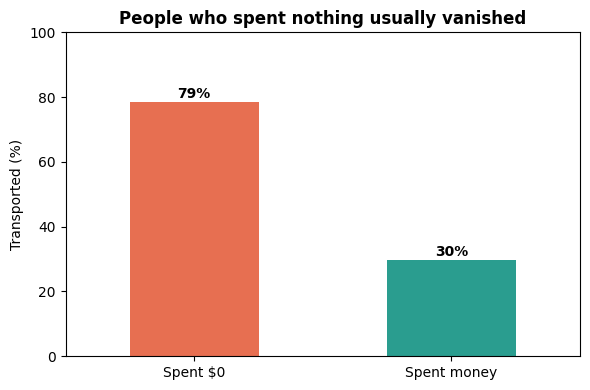

In [54]:
rates = train.groupby('Spent')['Transported'].mean() * 100
ax = rates.plot(kind='bar', color=['#E76F51','#2A9D8F'], figsize=(6,4))
plt.title('People who spent nothing usually vanished', fontsize=12, weight='bold')
plt.ylabel('Transported (%)'); plt.xlabel('')
plt.xticks([0,1], ['Spent $0','Spent money'], rotation=0)
for i, v in enumerate(rates):
    ax.text(i, v+1, f'{v:.0f}%', ha='center', weight='bold')
plt.ylim(0,100); plt.tight_layout(); plt.show()

## What the model leaned on

When I let the model weigh every clue, the same story rose to the top: sleep
status and spending dominated, followed by cabin location and travel group.
The model was not guessing randomly, it was using the exact clues a human
detective would.

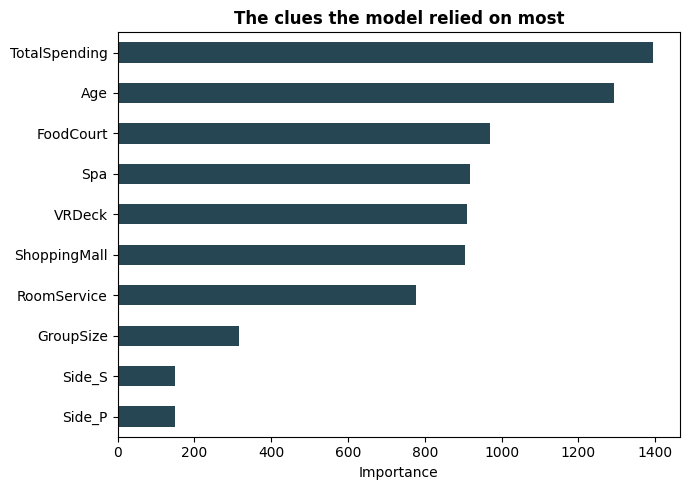

In [55]:
import pandas as pd
lgbm.fit(X, y)
imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot(kind='barh', color='#264653', figsize=(7,5))
plt.title('The clues the model relied on most', weight='bold')
plt.xlabel('Importance'); plt.ylabel(''); plt.tight_layout(); plt.show()

## Did it work?

Yes. Starting from a simple model and improving step by step, the final model
correctly predicted who was transported about **80%** of the time, both in my
own testing and on Kaggle's official scoreboard. The matching scores mean the
model is honest and not just memorizing.

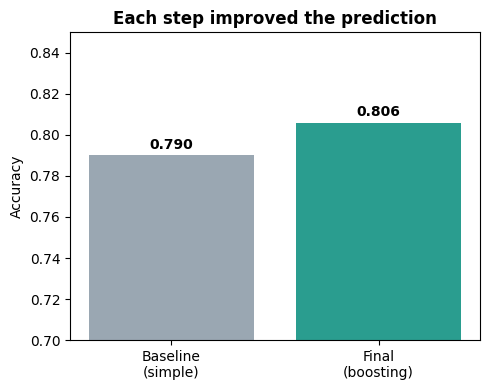

In [56]:
steps = ['Baseline\n(simple)', 'Final\n(boosting)']
scores = [0.790, 0.806]
ax = plt.subplots(figsize=(5,4))[1]
ax.bar(steps, scores, color=['#9AA7B2','#2A9D8F'])
plt.title('Each step improved the prediction', weight='bold')
plt.ylabel('Accuracy'); plt.ylim(0.7, 0.85)
for i, v in enumerate(scores):
    ax.text(i, v+0.003, f'{v:.3f}', ha='center', weight='bold')
plt.tight_layout(); plt.show()

In [47]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('gb', gb), ('lgbm', lgbm)],
    voting='soft'
)
scores = cross_val_score(ensemble, X, y, cv=cv)
print("Ensemble average:", scores.mean())

Ensemble average: 0.8045546856750734


In [48]:
gb.fit(X, y)
preds = gb.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': preds
})
submission.to_csv('/Users/ayeshashimu/Downloads/submission.csv', index=False)
print(submission.head())
print("Saved:", submission.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Saved: (4277, 2)


## The takeaway

Half the passengers vanished, but it was not random. The clearest predictor of
someone's fate was simply whether they were asleep, with their spending telling
the same story from another angle.

The lesson I take from this project: the best insight is rarely the fanciest
model, it is finding the one clue that explains the most, and telling that story
clearly.